<h1>Case Study I: USA</h1>
<h3>River Basin in upper Nevada, (BSk)</h3>

<h2>Data Used:</h2>

- Flo1K (Barbarossa et al. 2018): streamflow raster   
- Mindat (Von Bargen et al. 2025): collected from the API in this notebook  
- HydroSHEDS (Lehrer et al. 2008): Flow Direction & conditioned DEM raster  
- HydroBASINS (Lehner and Grill 2013): Basin vectors    
- Mining polygons (Tang and Werner 2023): Mining area vectors   

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
from data_utils import *
from classes import AMDModel
import contextily as cx
import matplotlib.colors as mcolors
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform


<h1>Configuration</h1>

In [2]:
new_model_initrun = True
time_first = "1960"
time_last = "2015"
region = "USA"
hydrobasins_region_code = "na"
basins_iloc = [47, 48]
case_study_nr = "CSI"
hybas_ids_of_interest = [7050073630]
metre_crs = "EPSG:26912" #(USA)
step_size = (52, "W")
ff = 1e-3
alpha_s = 1e-5
A_s_ratio = 0.4

<h2>Collect Mindat data </h2>
<p> Mindat data is used to filter if the mining polygons from Tang and Werner 2023, actually have the mineral of interest. For this case study the mineral is set as pyrite using keyword aguments: <b>material_name: "pyrite", mineral_id: 3314, material_strings: "(Fe|S)</b>.</p>
<p> The mindat_collector() function relies on the fact that you have access to the mindat API with an API key saved in the repository. The name of the file can be changed through the keyword argument: <b>mindat_api_str</b>.

In [3]:
mindat_collector(region)

File already exists, delete if you want new data


<h2>Flo1K preperation</h2>
<p>The Flo1K dataset is a large (24 GB) dataset, to make use a bit easier the raster is clipped by the area of interest (aoi) defined with the index locations (i:i) of basins in a HydroBASINS shapefile</p>
<p>Note that the file input and output locations can be changed through the use of keyword arguments, one especially of note is the <b>date</b> keyword argument which takes a pandas Timestamp object as input, only the year argument of this Timestamp should be changed, while the month and day should stay at 1, as the Flo1K dataset works on yearly data set to <b>year/01/01</b>.</p>

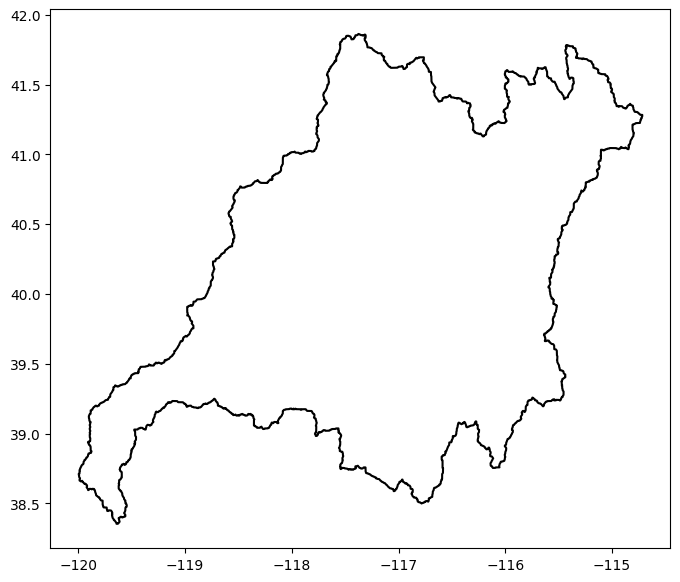

In [4]:
basins = gpd.read_file(f"../data/hybas_{hydrobasins_region_code}_lev05/hybas_{hydrobasins_region_code}_lev05_v1c.shp")

matching_rows = basins[basins["HYBAS_ID"].isin(hybas_ids_of_interest)]
if matching_rows.empty:
    print("No matching HYBAS_ID found.")
    print("Sample HYBAS_ID values:", basins["HYBAS_ID"].head(20).tolist())
    raise ValueError(f"HYBAS_ID not found: {hybas_ids_of_interest}")
iloc_indices = matching_rows.index.tolist()
iloc_tuple = tuple(iloc_indices)
aoi = basins.iloc[iloc_indices[0]:iloc_indices[-1] + 1]
basins_iloc[0] = iloc_indices[0]
basins_iloc[1] = iloc_indices[-1] + 1
aoi = basins.iloc[basins_iloc[0]: basins_iloc[1]]
ax = aoi.boundary.plot(figsize=(8, 8), edgecolor = "k")


In [5]:
time_array = np.ndarray(2, dtype = "datetime64[D]")
time_array[0] = np.datetime64(f"{time_first}-01-01")
time_array[-1] = np.datetime64(f"{time_last}-01-01")
flo_aoi_date = flo1k_prep(basins_iloc = basins_iloc, date= time_array, 
                          basins_path= f"../data/hybas_{hydrobasins_region_code}_lev04/hybas_{hydrobasins_region_code}_lev04_v1c.shp", 
                          aoi = aoi, length = step_size[0], frequency = step_size[1], time_first= time_first)

Splining complete!
Output shape: (2912, 420, 633) (Weeks: 2912, Lats: 420, Lons: 633)


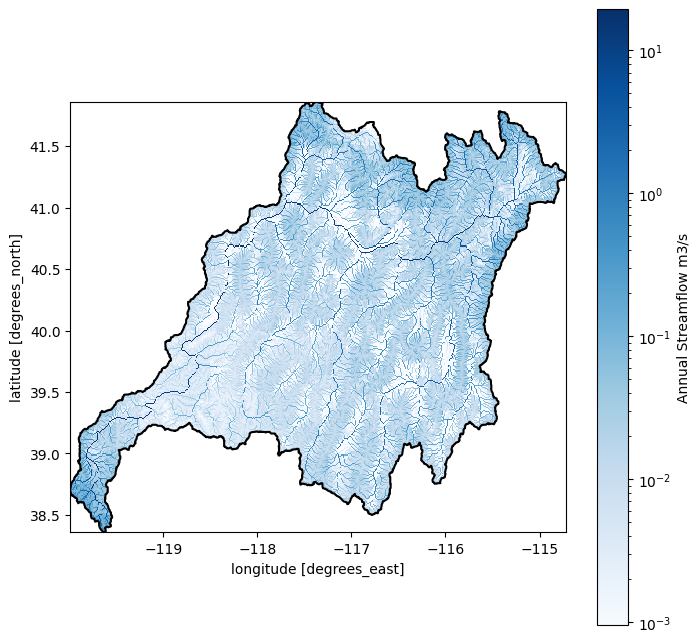

In [6]:
ax = aoi.boundary.plot(figsize=(8, 8), edgecolor = "k")
flo_aoi_date_plot = flo_aoi_date["Q"].where(flo_aoi_date["Q"] > 0)
flo_aoi_date_plot = flo_aoi_date_plot.isel(time = 0)
norm = mcolors.LogNorm(vmin = flo_aoi_date_plot.min(), vmax = flo_aoi_date_plot.max())
flo_aoi_date_plot.plot(ax = ax, cmap = "Blues", norm = norm, cbar_kwargs = {"label": "Annual Streamflow m3/s"})
plt.title("");

<h2>Flow Direction</h2>
<p>The model requires each cell in the raster to have an unique cell ID (ID), the IDs of where the flow goes to next (outID), and if the cell is the most upstream (source). To create this the HydroSHEDS hydir data is used </p>

In [7]:
hydir_ds = xr.open_dataset(f"../data/hyd_{hydrobasins_region_code}_dir_30s/hyd_{hydrobasins_region_code}_dir_30s.tif")
hydir_ds = hydir_ds.rename({"band_data": "hydir"})
hydir_ds_ids = hydir_IDs(hydir_ds, aoi)

Grid size: 6960 rows, 10320 cols


c:\Users\luuc_\miniconda3\envs\AMDFLOW\Lib\site-packages\xarray\core\duck_array_ops.py:268: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
c:\Users\luuc_\miniconda3\envs\AMDFLOW\Lib\site-packages\xarray\core\duck_array_ops.py:268: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


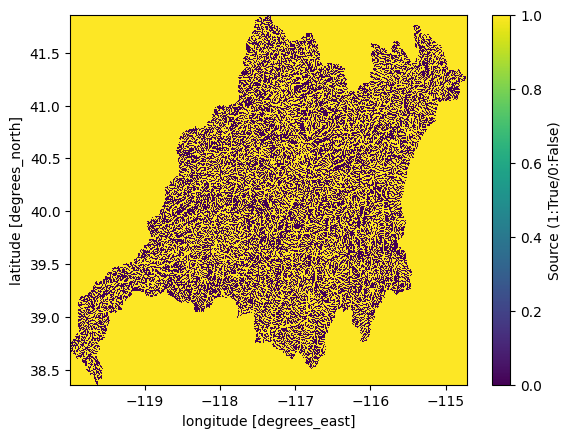

In [8]:
ax = hydir_ds_ids["source"].plot(cbar_kwargs = {"label": "Source (1:True/0:False)"})
plt.title("")
plt.show()
plt.close()

In [9]:
flw_da = rioxarray.open_rasterio(f"../data/hyd_{hydrobasins_region_code}_dir_30s/hyd_{hydrobasins_region_code}_dir_30s.tif")
flo_aoi_date = flo_aoi_date.rio.write_crs("EPSG:4326")
flw_da_align = flw_da.rio.reproject_match(flo_aoi_date)

flwdir = flw_da_align.values[0]
transform = flw_da_align.rio.transform()
crs = flw_da_align.rio.crs
latlon = crs.to_epsg() == 4326
ref = flo_aoi_date
flwdir
flw = pyflwdir.from_array(
    flwdir, ftype="d8", transform=transform, latlon=latlon, cache=True
)
Q = flo_aoi_date["Q"].values
for t in range(len(flo_aoi_date.time)):
    Q2d = Q[t, :, :].copy()
    
    Q2d = np.where(np.isnan(Q2d), 0.0, Q2d)
    q_accumulated = flw.accuflux(
        data=Q2d,
        nodata=-9999.0
    )
    
    Q[t, :, :] = q_accumulated
flo_aoi_date["Q"].values = Q

<h2>Slope from Conditioned DEM </h2>

In [10]:
# resampling of 3s to 30s of DEM
original_res_deg = 3 / 3600          
downscale_factor = 1/10
target_res = original_res_deg / downscale_factor 


with rasterio.open(f"../data/{hydrobasins_region_code}_con_3s.tif") as src:
    # Get bounds from GeoDataFrame (assuming aoi is a GeoDataFrame with one row)
    left, bottom, right, top = aoi.total_bounds  # or aoi.geometry.iloc[0].bounds

    dst_crs = src.crs
    dst_transform, dst_width, dst_height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height,
        left, bottom, right, top,
        resolution=target_res
    )

    dem_resampled = np.empty((dst_height, dst_width), dtype=np.float32)

    reproject(
        source=rasterio.band(src, 1),
        destination=dem_resampled,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear
    )

# deriving stream slope from dem
S = pyflwdir.dem.slope(dem_resampled, latlon = True)
height, width = dem_resampled.shape
x_coords = dst_transform.c + (np.arange(width) + 0.5) * dst_transform.a   # cell centers
y_coords = dst_transform.f + (np.arange(height) + 0.5) * dst_transform.e

# Alternatively, for cell corners (if you prefer)
# x_coords = dst_transform.c + np.arange(width) * dst_transform.a
# y_coords = dst_transform.f + np.arange(height) * dst_transform.e

# 3. Build DataArray
da_slope = xr.DataArray(
    S,
    dims = ("y", "x"),
    coords = {"y": y_coords, "x": x_coords},
    attrs = {"units": "m/m", "long_name": "terrain slope"},
    name = "slope"
)
da_slope.rio.write_crs(dst_crs, inplace = True)

<xarray.DataArray 'slope' (y: 422, x: 634)> Size: 1MB
array([[1.1712275e-04, 2.6166110e-04, 2.1646000e-04, ..., 3.0904228e-04,
        1.4783406e-04, 3.6114448e-05],
       [1.2560187e-04, 3.4453411e-04, 3.5517712e-04, ..., 3.7292647e-04,
        1.9816593e-04, 9.3199727e-05],
       [1.0499212e-04, 3.0043075e-04, 4.0878088e-04, ..., 2.7015948e-04,
        1.7116763e-04, 8.6692977e-05],
       ...,
       [4.0261398e-04, 1.0157782e-03, 1.4362135e-03, ..., 5.0487614e-04,
        6.4562290e-04, 3.4646844e-04],
       [1.6344752e-04, 6.5325719e-04, 1.4106060e-03, ..., 5.3757394e-04,
        6.9549348e-04, 4.0319967e-04],
       [1.2217362e-04, 3.0050665e-04, 1.0815655e-03, ..., 4.2866013e-04,
        5.4552098e-04, 2.9270072e-04]], shape=(422, 634), dtype=float32)
Coordinates:
  * y            (y) float64 3kB 41.86 41.85 41.84 41.83 ... 38.37 38.36 38.35
  * x            (x) float64 5kB -120.0 -120.0 -120.0 ... -114.7 -114.7 -114.7
    spatial_ref  int64 8B 0
Attributes:
    units:      m/m
    long_name:  terrain slope

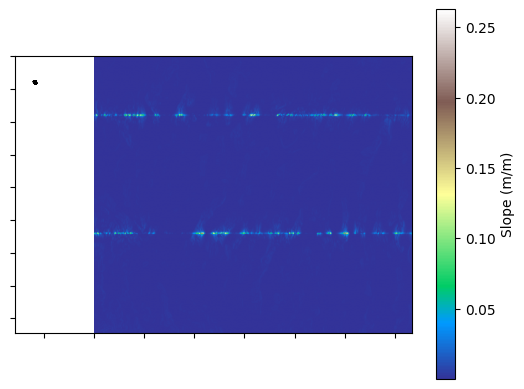

In [11]:
S = np.asarray(S)
S_masked = np.ma.masked_equal(S, 0)

fig, ax = plt.subplots()
cmap = plt.cm.terrain
cmap.set_bad("white") 

im = ax.imshow(S_masked, cmap=cmap)
fig.colorbar(im, ax=ax, label="Slope (m/m)")
aoi.boundary.plot(ax = ax, edgecolor = "k")
ax.set_xticklabels([])
ax.set_yticklabels([]);

<h2>Mining Polygons and Mineral Occurences</h2>
<p>Because no good dataset exists where mining areas are matched with what ores are present this matching has to be here. The principle is as follows, the mining polygons (Tang and Werner 2013) are first converted to raster datasets (to align with the other datasets) with a bolean array of mine or no mine. The mindat mineral occurences are points on a map, but all have some error associated with them, thus the mineral points get a buffer of around 5km/0.045 degrees. If a mine cell intersects with the buffer of a mineral occurence the mine is kept, if not the mine likely does not have the mineral and is dropped. </p>

In [12]:
vector_rasterisation(flo1k_path=f"../data/flo_{case_study_nr}_{time_first}-{time_last}.nc")

mines_raster = xr.open_dataset("../data/mines_raster.tif")
mineral_points = gpd.read_file(f"../data/mindat_data/{region}_pyrite.csv")
mineral_points = gpd.points_from_xy(mineral_points["longitude"], mineral_points["latitude"], crs = "EPSG:4326")
mineral_points = gpd.GeoDataFrame(mineral_points).set_geometry(col = 0)

filtered_mines_raster = filter_mines_with_buffer(mines_raster, mineral_points, metre_crs)

Raster saved to ../data/mines_raster.tif


<h2>Merging Datasets</h2>
<p>For the model a single dataset is used, thus the different datasets are merged using xarray.merge.</p>   
<p>Note that labels, descriptions and units are changed in the function cleanup_and_metadata() in the funcs file </p>

In [13]:
# convert bools to ints
hydir_ds_ids_num = bool_to_int(hydir_ds_ids.copy())   

# reproject
flo_aoi_date = flo_aoi_date.rio.write_crs("EPSG:4326")
ref = flo_aoi_date

hydir_aligned = hydir_ds_ids_num.rio.reproject_match(ref)
mines_aligned = filtered_mines_raster.rio.reproject_match(ref)
slope_aligned = da_slope.rio.reproject_match(ref)
# merge
ds_combined = xr.merge([ref, hydir_aligned, mines_aligned, slope_aligned])

# cleanup
ds = cleanup_and_metadata(ds_combined)

C:\Users\luuc_\AppData\Local\Temp\ipykernel_2708\219531941.py:12: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_combined = xr.merge([ref, hydir_aligned, mines_aligned, slope_aligned])


<h2>Estimating Ore amounts</h2>
<p>For each cell of "mines", a reactive ore amount must be estimated. This is done using the equation:       


$$
reactive_{ore} = 27000f_{f}
$$

In [14]:
ds = estimate_ore(ds, ff, ox_range=94) 

In [15]:
ds

<xarray.Dataset> Size: 6GB
Dimensions:      (time: 2912, lat: 420, lon: 633)
Coordinates:
  * time         (time) datetime64[ns] 23kB 1960-01-04 1960-01-11 ... 2015-10-19
  * lat          (lat) float64 3kB 38.36 38.37 38.38 38.39 ... 41.84 41.85 41.85
  * lon          (lon) float64 5kB -120.0 -120.0 -120.0 ... -114.7 -114.7 -114.7
    spatial_ref  int64 8B 0
Data variables:
    Q            (time, lat, lon) float64 6GB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ID           (lat, lon) int64 2MB -9223372036854775807 ... -9223372036854...
    outID        (lat, lon) int64 2MB -9223372036854775807 ... -9223372036854...
    source       (lat, lon) int16 532kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    slope        (lat, lon) float32 1MB 0.0006533 0.001411 ... 9.32e-05
    ore          (lat, lon) float64 2MB nan nan nan nan nan ... nan nan nan nan

<Axes: title={'center': 'spatial_ref = 0'}, xlabel='lon', ylabel='lat'>

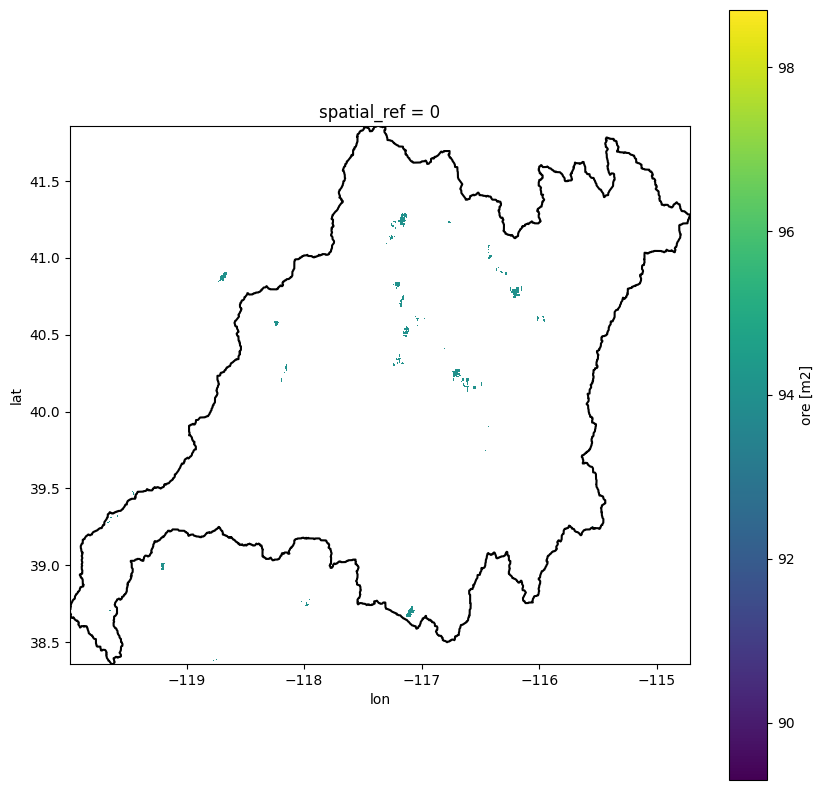

In [16]:
fig, ax = plt.subplots(figsize = (10, 10))
ds["ore"].plot(ax = ax)
aoi.boundary.plot(ax = ax, edgecolor = "k")

<h2>Modelling</h2>

In [17]:
if new_model_initrun:
    model = AMDModel(ds, "week", output_path= f"../data/validation data/AMDFLOW_{case_study_nr}_{time_first}-{time_last}_W.nc",
                     alpha_s = alpha_s, A_s_ratio= A_s_ratio)

Network mask built: 2,574 / 265,860 cells on AMD network


In [18]:
if new_model_initrun:
    model.run()

2912it [1:07:43,  1.40s/it]


In [19]:
if new_model_initrun:
    model.dataset

<h2> Validation </h2>

In [ ]:
from val_utils import *
case_study_nr = "CSI"
times = (time_first, time_last)
caravan_path = "../data/validation data/Caravan-Qual_lite.zarr"
amd_path = f"../data/validation data/AMDFLOW_{case_study_nr}_{times[0]}-{times[1]}_W.nc"
output_path = f"../data/validation data/{case_study_nr}/"
acc_path = f"../data/validation data/hyd_{hydrobasins_region_code}_acc_30s.tif"
rivers_path = f"../data/validation data/HydroRIVERS_v10_{hydrobasins_region_code}_shp/HydroRIVERS_v10_{hydrobasins_region_code}.shp"

utm_crs = metre_crs
resample_freq = "W"
var_map = {
    "pH": "pH",
    "Fe-Dis": ["ferrous_iron", "ferric_iron"],
    "Fe-Tot": ["ferrous_iron", "ferric_iron", "ferric_oxyhydroxide"],
}

print(f"Validating AMDFLOW Case Study {case_study_nr} ({times[0]}–{times[1]}),")
print("against Caravan-Qual Lite using HydroSHEDS network + area ratio snapping.")

# load everything
amd, caravan, acc_array, acc_transform, acc_nodata, rivers= load_datasets(
    amd_path, caravan_path, acc_path, rivers_path
)

candidates = wqms_stations_domain_filter(amd, caravan)

# get masks
(valid_ilat, valid_ilon, valid_lat, valid_lon,
    iron_ilat, iron_ilon, iron_lat, iron_lon,
    valid_mask, iron_mask) = valid_masking(amd)

# build river graph
river_graph = build_river_graph(rivers)

# 2D lat/lon grids
lat_vals = amd.lat.values
lon_vals = amd.lon.values
amd_lat_2d, amd_lon_2d = np.meshgrid(lat_vals, lon_vals, indexing="ij")

# upstream areas from ACC
uparea_dict = assign_uparea_from_acc(amd, amd_lat_2d, amd_lon_2d, valid_mask,
                                        acc_array, acc_transform, acc_nodata)
 
# snap AMD cells to river network (once)
cell_to_river = snap_cells_to_river(amd_lat_2d, amd_lon_2d, valid_mask, rivers, utm_crs)
print(f"Cells snapped to river: {len(cell_to_river)}")
# snap stations for pH mask
matches_ph = snap_stations_hydrosheds(
    candidates, amd_lat_2d, amd_lon_2d, valid_mask,
    uparea_dict, cell_to_river, rivers, river_graph, utm_crs,
    max_network_km=15.0, area_ratio_min=0.5, area_ratio_max=1.5
)

# snap stations for iron mask
iron_cells = [(ilat, ilon) for ilat, ilon in zip(*np.where(iron_mask))]
iron_uparea_dict = {k: uparea_dict.get(k, np.nan) for k in iron_cells}
iron_cell_to_river = {k: v for k, v in cell_to_river.items() if k in iron_cells}

matches_iron = snap_stations_hydrosheds(
    candidates, amd_lat_2d, amd_lon_2d, iron_mask,
    iron_uparea_dict, iron_cell_to_river, rivers, river_graph, utm_crs,
    max_network_km=15.0, area_ratio_min=0.5, area_ratio_max=1.5
)

print(f"  pH mask:   {len(matches_ph)} stations matched")
print(f"  Iron mask: {len(matches_iron)} stations matched")

# run full validation
all_results = full_run(var_map, matches_ph, matches_iron, amd, caravan,
                        min_paired_obs=3, resample_freq=resample_freq)

for var, ts in all_results.items():
    print(f"\n── {var} ──────────────────────────────────────────")
    metrics = validation_metrics(ts)
    
    # add coordinates for matched stations (pH and iron may differ)
    if var in ["Fe-Dis", "Fe-Tot"]:
        match_df = matches_iron
    else:
        match_df = matches_ph
    
    coords = match_df[["wqms_id", "cell_lat", "cell_lon"]].set_index("wqms_id")
    results_df = metrics.join(coords)
    
    os.makedirs(output_path, exist_ok=True)
    results_df.to_csv(f"{output_path}metrics_{var}.csv")
    print(f"  Saved → {output_path}metrics_{var}.csv\n  With {len(results_df)} matched stations and their metrics.")

Validating AMDFLOW Case Study CSI (1960–2015),
against Caravan-Qual Lite using HydroSHEDS network + area ratio snapping.

Loading all datasets.....
384 stations fall inside (or near) the AMD domain

Computing valid-cell mask …
  2,574 valid cells (pH mask)
  2,574 iron cells
Assigning upstream watershed area to cells from flow accumulation
Snapping cells to river(s)
Cells snapped to river: 2574
Snapping stations to rivers and then cells
Snapping stations to rivers and then cells
  pH mask:   49 stations matched
  Iron mask: 49 stations matched
  Overlapping period: 1980-01-01 → 2015-10-19
  Reading 19 unique AMD cells (covers 49 stations) …
  AMD variable(s): pH
  693 / 91,532 timesteps have paired observations (0.8 %)
  Recording 23 station(s) with < 3 paired observations
  Overlapping period: 1980-01-01 → 2015-10-19
  Reading 19 unique AMD cells (covers 49 stations) …
  AMD variable(s): ferrous_iron+ferric_iron
  150 / 91,532 timesteps have paired observations (0.2 %)
  Recording 13 

In [21]:
output = xr.open_dataset(f"../data/validation data/AMDFLOW_{case_study_nr}_{time_first}-{time_last}_W.nc")

In [22]:
ferric_iron = output["ferric_iron"]
ferrous_iron = output["ferrous_iron"]
sulphate = output["sulphate"]
hydron = output["hydrogen_ion"]
ferric_oxyhydroxide = output["ferric_oxyhydroxide"]
ph = output["pH"]
bedload_storage = output["bedload_storage"]
output.close()

In [23]:
validation_ph = pd.read_csv(f"../data/validation data/{case_study_nr}/Metrics_pH.csv").dropna()
display(validation_ph)
try:
    best_fze_ph = validation_ph.sort_values("FZE", ascending = False).iloc[0]
except:
    pass

,wqms_id,n,RMSE,bias,NSE,KGE,R,FZE,cell_lat,cell_lon
0,wqms_23203422,75,1.377110,-1.186068,-2.961291,-0.010954,-20.808544,0.127542,39.179165,-119.695830
1,wqms_23203423,238,1.519286,-1.430001,-11.576870,-0.057469,-26.434174,-0.044738,39.295834,-119.312500
3,wqms_23211827,29,0.889250,-0.795188,-5.097254,0.098914,-12.583219,-0.102159,39.095833,-119.729164
4,wqms_23211828,85,1.364434,-1.284951,-11.677970,0.100928,-18.095459,0.111933,39.295834,-119.312500
6,wqms_23211923,4,0.801067,-0.738107,-12.028083,0.134353,-8.872426,0.001506,39.179165,-119.704170
9,wqms_23223241,3,3.647645,-3.647413,-773.705210,0.178197,-497.950134,0.512880,40.887500,-116.245834
10,wqms_23223248,7,0.287594,-0.063315,-1.914654,-0.239051,-1.329207,-0.234806,39.912500,-116.412500
12,wqms_23223283,16,1.766751,1.133421,-38.608416,-2.566295,-1.238588,-0.746185,38.745834,-119.645836
14,wqms_23223295,3,0.800263,-0.736223,-8.331770,0.012195,-17.011805,-0.121172,39.095833,-119.729164
16,wqms_23229302,28,1.572658,-1.172341,-1.364434,-0.158344,-22.387192,0.061066,39.179165,-119.695830


In [24]:
validation_fe_dis = pd.read_csv(f"../data/validation data/{case_study_nr}/Metrics_Fe-Dis.csv")
display(validation_fe_dis)
try:
    best_fze_fe_dis = validation_fe_dis.sort_values("FZE", ascending = False).iloc[0]
except:
    pass

,wqms_id,n,RMSE,bias,NSE,KGE,R,FZE,cell_lat,cell_lon
0,wqms_23203422,27,139.585631,-96.468361,-3.931031,-5.975106,-3.490709,-0.798662,39.179165,-119.695830
1,wqms_23203423,16,83.649100,-71.120193,-1232.211881,-22.311879,-2.599715,-0.638840,39.295834,-119.312500
2,wqms_23211825,1,NaN,-76.345276,NaN,NaN,NaN,NaN,39.095833,-119.729164
3,wqms_23211827,23,73.021294,-51.868980,-4373.124787,-52.792392,-1.046595,-0.904716,39.095833,-119.729164
4,wqms_23211828,62,76.857661,-52.165195,-901.015134,-23.689110,-0.873233,-0.715505,39.295834,-119.312500
5,wqms_23223240,1,NaN,1391.821411,NaN,NaN,NaN,NaN,40.979168,-116.362500
6,wqms_23223241,3,5794.210904,5547.974609,-10.443529,-0.401859,-11441.699219,-90.248338,40.887500,-116.245834
7,wqms_23223248,2,NaN,-5.850000,NaN,NaN,NaN,NaN,39.912500,-116.412500
8,wqms_23223253,1,NaN,25596.347656,NaN,NaN,NaN,NaN,40.895832,-116.495834
9,wqms_23223283,3,303.670630,-2.714106,-7.434448,-1.856702,0.432878,0.277085,38.745834,-119.645836


In [25]:
validation_fe_tot = pd.read_csv(f"../data/validation data/{case_study_nr}/Metrics_Fe-Tot.csv")
try:
    display(validation_fe_tot)
    best_fze_fe_tot = validation_fe_tot.sort_values("FZE", ascending=False).iloc[0]
except:
    pass

,wqms_id,n,RMSE,bias,NSE,KGE,R,FZE,cell_lat,cell_lon


In [26]:
caravan = xr.open_dataset("../data/validation data/Caravan-Qual_lite.zarr", engine="zarr",
                               chunks={})

In [27]:
obs_fe_dis = caravan.sel(wqms_id = best_fze_fe_dis["wqms_id"])["Fe-Dis"]
obs_ph = caravan.sel(wqms_id = best_fze_ph["wqms_id"])["pH"]

In [28]:
model_fe_dis = ferric_iron.sel(lat = best_fze_fe_dis["cell_lat"], lon = best_fze_fe_dis["cell_lon"]) + \
        ferrous_iron.sel(lat = best_fze_fe_dis["cell_lat"], lon = best_fze_fe_dis["cell_lon"])
        

model_ph = ph.sel(lat = best_fze_ph["cell_lat"], lon = best_fze_ph["cell_lon"])

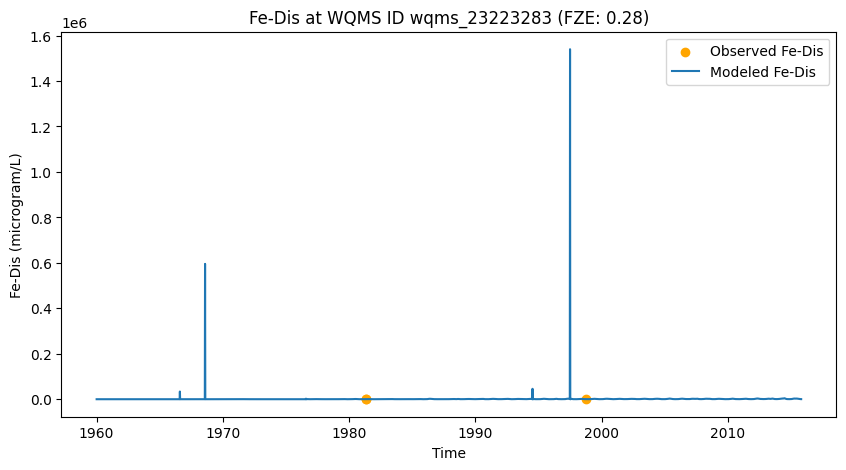

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(obs_fe_dis.time, obs_fe_dis.values, label = "Observed Fe-Dis", marker = "o", color = "orange")
model_fe_dis.plot(ax = ax, label = "Modeled Fe-Dis")
plt.legend()
plt.title(f"Fe-Dis at WQMS ID {best_fze_fe_dis['wqms_id']} (FZE: {best_fze_fe_dis['FZE']:.2f})")
plt.xlabel("Time")
plt.ylabel("Fe-Dis (microgram/L)");

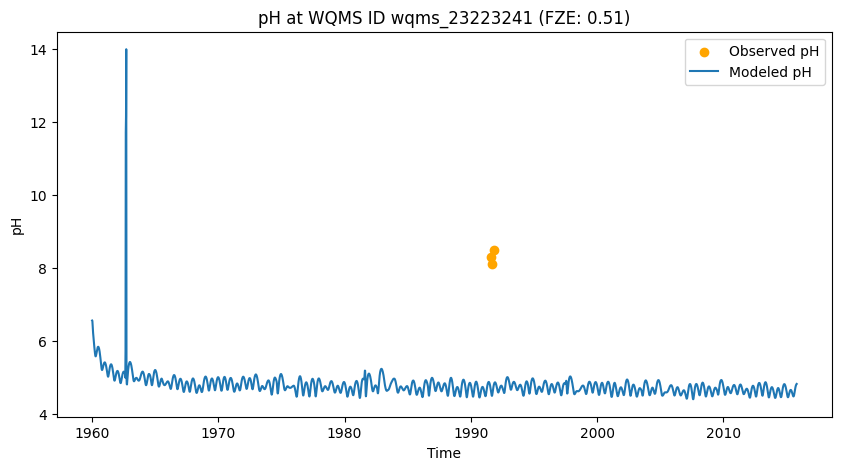

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(obs_ph.time, obs_ph.values, label = "Observed pH", marker = "o", color = "orange")
model_ph.plot(ax = ax, label = "Modeled pH")
plt.legend()
plt.title(f"pH at WQMS ID {best_fze_ph['wqms_id']} (FZE: {best_fze_ph['FZE']:.2f})")
plt.xlabel("Time")
plt.ylabel("pH");

<Axes: title={'center': 'time = 2015-10-19'}, xlabel='lon', ylabel='lat'>

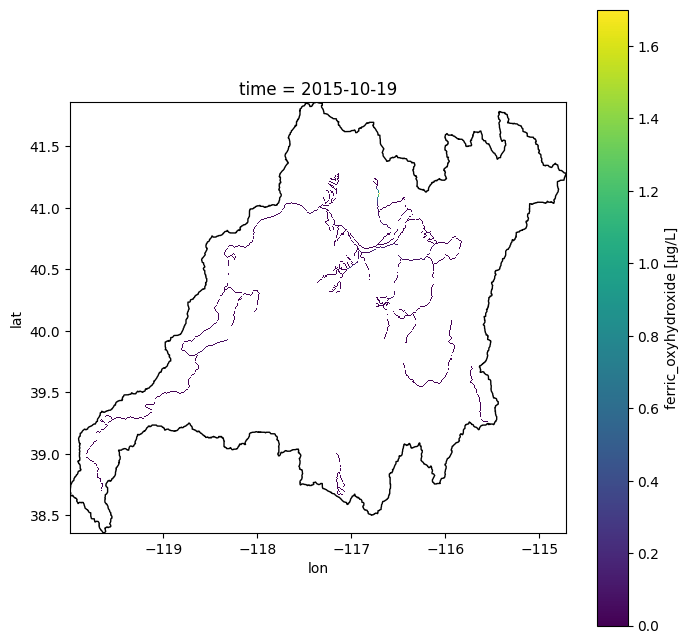

In [31]:
var = ferric_oxyhydroxide
fig, ax = plt.subplots(figsize=(8, 8))
var.isel(time = -1).where(var.isel(time = -1) > 0).plot(ax = ax)
aoi.plot(ax = ax, facecolor = "None", edgecolor = "k")



<Axes: title={'center': 'time = 2015-10-19'}, xlabel='lon', ylabel='lat'>

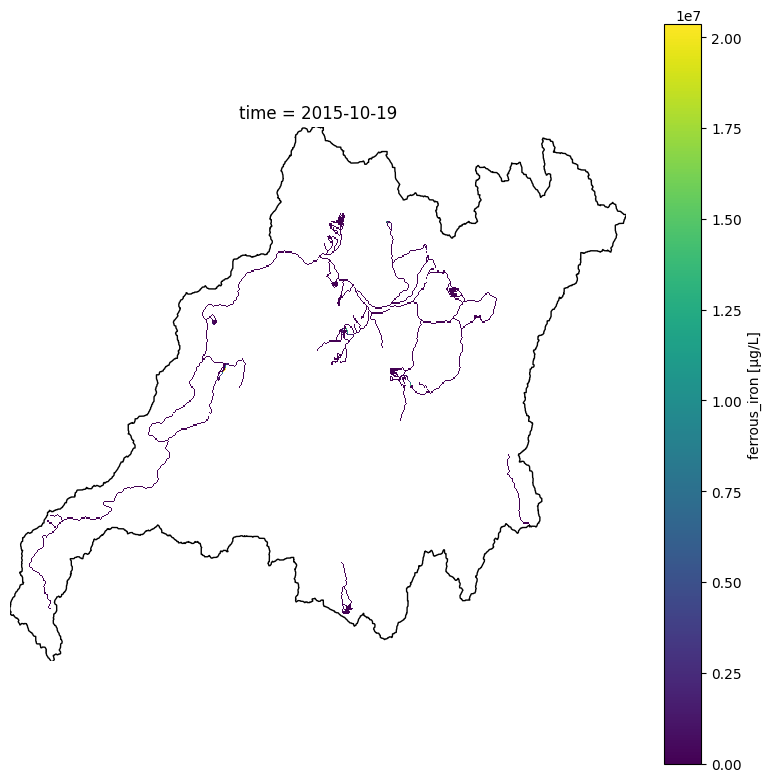

In [32]:
var = ferrous_iron
fig, ax = plt.subplots(figsize=(8, 8))
var.isel(time = -1).where(var.isel(time = -1) > 0).plot(ax = ax)
ax.set_axis_off()
plt.tight_layout()
aoi.plot(ax = ax, facecolor = "None", edgecolor = "k")